# Klasifikacija proteinskih sekvenci prema biološkoj funkciji

In [1]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

## Priprema podataka

### Definisanje klasa

In [2]:
CLASSES = {
    "Hydrolase": "hydrolase.tsv",
    "Transport protein": "transport_protein.tsv",
    "Transcription factor": "transcription_factor.tsv",
    "Receptor": "receptor.tsv",
    "Structural protein": "structural_protein.tsv"
}

### Učitavanje i spajanje TSV fajlova

In [3]:
all_dfs = []
for label, filename in CLASSES.items():
    df = pd.read_csv(f"data\\{filename}", sep="\t")
    df["label"] = label
    print(f"{label}: {len(df)} proteina")
    all_dfs.append(df)

Hydrolase: 2407 proteina
Transport protein: 1242 proteina
Transcription factor: 1418 proteina
Receptor: 1605 proteina
Structural protein: 774 proteina


In [4]:
dataset = pd.concat(all_dfs, ignore_index=True)
os.makedirs("data", exist_ok=True)
dataset.to_csv(os.path.join("data", "uniprot_protein.csv"), index=False)
print(f"CSV fajl 'uniprot_protein.csv' je uspjesno kreiran!")

CSV fajl 'uniprot_protein.csv' je uspjesno kreiran!


## Upoznavanje sa skupom podataka

### Osnovne informacije

In [5]:
print(f"\nUkupan broj proteina: {len(dataset)}")
print(f"Broj klasa: {dataset['label'].nunique()}")
print(f"Dimenzije dataseta: {dataset.shape}")
print(f"\nKolone: {list(dataset.columns)}")


Ukupan broj proteina: 7446
Broj klasa: 5
Dimenzije dataseta: (7446, 5)

Kolone: ['Entry', 'Sequence', 'Protein names', 'Keywords', 'label']


In [6]:
# Prikaz prvih 5 redova dataseta
dataset.head()

,Entry,Sequence,Protein names,Keywords,label
0,A0A1B0GTW7,MLLLLLLLLLLPPLVLRVAASRCLHDETQKSVSLLRPPFSQLPSKS...,Ciliated left-right organizer metallopeptidase...,Alternative splicing;Disease variant;Glycoprot...,Hydrolase
1,A1A4Y4,MEAMNVEKASADGNLPEVISNIKETLKIVSRTPVNITMAGDSGNGM...,Immunity-related GTPase family M protein (EC 3...,Alternative splicing;Autophagy;Cell membrane;C...,Hydrolase
2,A1KZ92,MEPRLFCWTTLFLLAGWCLPGLPCPSRCLCFKSTVRCMHLMLDHIP...,Probable oxidoreductase PXDNL (EC 1.-.-.-) (Ca...,Alternative splicing;Calcium;Cell membrane;Cyt...,Hydrolase
3,A1Z1Q3,MYPSNKKKKVWREEKERLLKMTLEERRKEYLRDYIPLNSILSWKEE...,ADP-ribose glycohydrolase MACROD2 (MACRO domai...,3D-structure;Alternative splicing;DNA damage;H...,Hydrolase
4,A2A288,MEHPSKMEFFQKLGYDREDVLRVLGKLGEGALVNDVLQELIRTGSR...,Probable ribonuclease ZC3H12D (EC 3.1.-.-) (MC...,Alternative splicing;Chromosomal rearrangement...,Hydrolase


## Predprocesiranje podataka

### Uklanjanje duplikata

In [7]:
# Broj unikatnih sekvenci koje se ponavljaju više puta u datasetu
mask = dataset['Sequence'].duplicated(keep=False)
dup_df = dataset[mask]
multifunk = dup_df.groupby('Sequence').apply(list)
print(f"Broj unikatnih sekvenci sa duplikatima: {multifunk.shape[0]}")

Broj unikatnih sekvenci sa duplikatima: 386


In [8]:
cls_per_seq = dup_df.groupby('Sequence')['label'].nunique()
print(f"Sekvence sa istom klasom: {(cls_per_seq == 1).sum()}")
print(f"Sekvence sa razlicitim klasama (multifunkcionalni): {(cls_per_seq > 1).sum()}")

Sekvence sa istom klasom: 6
Sekvence sa razlicitim klasama (multifunkcionalni): 380


In [9]:
labels = dup_df.groupby('Sequence')['label']
combinations = labels.apply(lambda x: tuple(sorted(set(x))))

multifunk_comb = combinations[combinations.apply(len) > 1]

print("Kombinacije klasa kod multifunkcionalnih sekvenci:")
print(multifunk_comb.value_counts().sort_index(ascending=True))

Kombinacije klasa kod multifunkcionalnih sekvenci:
label
(Hydrolase, Receptor)                                   52
(Hydrolase, Receptor, Transcription factor)              2
(Hydrolase, Receptor, Transport protein)                 4
(Hydrolase, Structural protein)                         38
(Hydrolase, Transcription factor)                        4
(Hydrolase, Transcription factor, Transport protein)     1
(Hydrolase, Transport protein)                          98
(Receptor, Structural protein)                           7
(Receptor, Structural protein, Transport protein)        1
(Receptor, Transcription factor)                        58
(Receptor, Transcription factor, Transport protein)      1
(Receptor, Transport protein)                           99
(Structural protein, Transcription factor)               1
(Structural protein, Transport protein)                 13
(Transcription factor, Transport protein)                1
Name: count, dtype: int64


In [9]:
# Pronalazimo sekvence koje imaju vise od jedne klase
multifunk_seq = cls_per_seq[cls_per_seq>1].index
# Kreiramo dataset koji iskljucuje te sekvence
dataset_clean = dataset[~dataset['Sequence'].isin(multifunk_seq)]

# Ispisujemo broj 'pravih' duplikata
duplicates = dataset_clean['Sequence'].duplicated().sum()
print(f"Broj duplikata: {duplicates}")

# Brisemo 'prave' duplikate
dataset = dataset_clean.drop_duplicates(subset="Sequence").reset_index(drop=True)
print(f"Ukupno proteina nakon uklanjanja duplikata: {len(dataset)}")

Broj duplikata: 11
Ukupno proteina nakon uklanjanja duplikata: 6664


In [10]:
# Distribucija klasa nakon uklanjanja duplikata
print(dataset['label'].value_counts())

label
Hydrolase               2204
Receptor                1379
Transcription factor    1346
Transport protein       1023
Structural protein       712
Name: count, dtype: int64


### Uklanjanje nedostajućih vrijednosti

In [11]:
# Redovi sa praznom sekvencom
print(f"Broj redova sa praznom sekvencom: {dataset['Sequence'].isna().sum()}")

Broj redova sa praznom sekvencom: 0


### Uklanjanje sekvenci sa nestandardnim aminokiselinama

Proteinske sekvence se predstavljaju pomoću 20 standardnih aminokiselina (A, C, D, E, F, G, H, I, K, L, M, N, P, Q, R, S, T, V, W, Y).

Sekvence koje sadrže nestandardne oznake (X, B, Z, U, O) su uklonjene iz dataseta jer predstavljaju neodređene ili modifikovane aminokiseline.

In [12]:
def valid_sequence(seq):
    valid_aa = set("ACDEFGHIKLMNPQRSTVWY")
    seq = str(seq).upper().strip()

    unvalid = [aa for aa in seq if aa not in valid_aa]
    if unvalid:
        print(f"Nevalidni karakteri: {set(unvalid)}")
        return None
    
    if len(seq) < 10:
        print(f"Prekratka sekvenca: {len(seq)}")
        return None
    
    return seq

dataset['Sequence'] = dataset['Sequence'].apply(valid_sequence)

total_before = len(dataset)
dataset = dataset.dropna(subset=['Sequence'])
total_after = len(dataset)

print(f"Prije odbacivanja: {total_before} proteina")
print(f"Nakon odbacivanja: {total_after} proteina")

Nevalidni karakteri: {'U'}
Prije odbacivanja: 6664 proteina
Nakon odbacivanja: 6663 proteina


## Eksploratorna analiza podataka (EDA)

### Vizualizacija distribucije klasa

U cilju boljeg razumijevanja strukture dataseta, prikazana je distribucija proteina po klasama. Analiza distribucije omogućava uočavanja neuravnoteženosti između klasa.

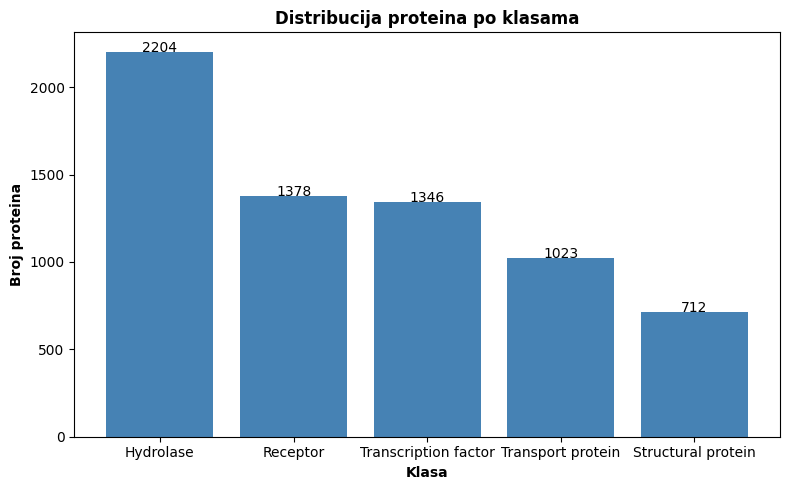

In [13]:
class_counts = dataset["label"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(class_counts.index, class_counts.values, color="steelblue")
plt.title("Distribucija proteina po klasama", fontweight="bold")
plt.xlabel("Klasa", fontweight="bold")
plt.ylabel("Broj proteina", fontweight="bold")

for i, v in enumerate(class_counts.values):
    plt.text(i, v, str(v), ha="center")

plt.tight_layout()
plt.savefig("results/fig1_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Statistički pregled dužina sekvenci po klasi

U ovom koraku analiziramo distribuciju dužina proteinskih sekvenci unutar svake funkcionalne klase. Različite funkcije proteina često zahtijevaju različite strukturne kompleksnosti, što se odražava na broj aminokiselina u sekvencama.

In [14]:
dataset["seq_length"] = dataset["Sequence"].str.len()

stats_df = dataset.groupby("label")["seq_length"].describe().round(1)
print(stats_df)

                       count   mean     std   min    25%    50%    75%  \
label                                                                    
Hydrolase             2204.0  605.6   465.7  68.0  303.8  480.0  755.0   
Receptor              1378.0  512.2   436.8  85.0  312.0  345.0  516.5   
Structural protein     712.0  814.5  1661.2  25.0  175.0  398.0  849.2   
Transcription factor  1346.0  541.2   336.5  34.0  350.2  483.0  630.0   
Transport protein     1023.0  581.8   527.3  55.0  310.0  484.0  669.5   

                          max  
label                          
Hydrolase              5596.0  
Receptor               5079.0  
Structural protein    34350.0  
Transcription factor   3953.0  
Transport protein      5038.0  


#### Histogram raspodjele po klasama

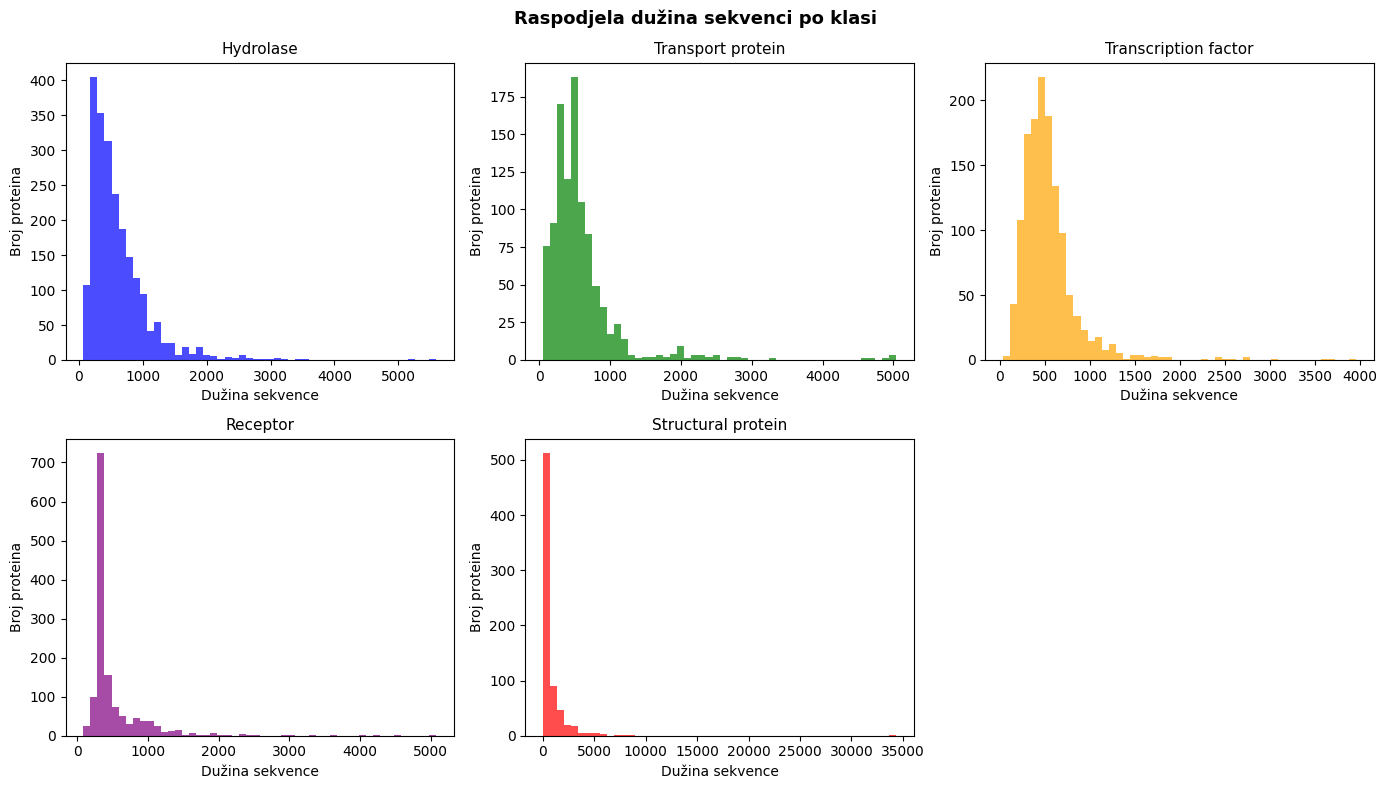

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

classes = dataset['label'].unique()
colors = ['blue', 'green', 'orange', 'purple', 'red']

for i, (cls, color) in enumerate(zip(classes, colors)):
    subset = dataset[dataset['label'] == cls]['seq_length']
    axes[i].hist(subset, bins=50, color=color, alpha=0.7)
    axes[i].set_title(cls, fontsize=11)
    axes[i].set_xlabel("Dužina sekvence")
    axes[i].set_ylabel("Broj proteina")

axes[5].set_visible(False)
plt.suptitle("Raspodjela dužina sekvenci po klasi", fontsize=13, fontweight="bold")
plt.tight_layout()

plt.savefig("results/fig2_length_histograms.png", dpi=300, bbox_inches="tight")
plt.show()

#### Box plot distribucije dužina

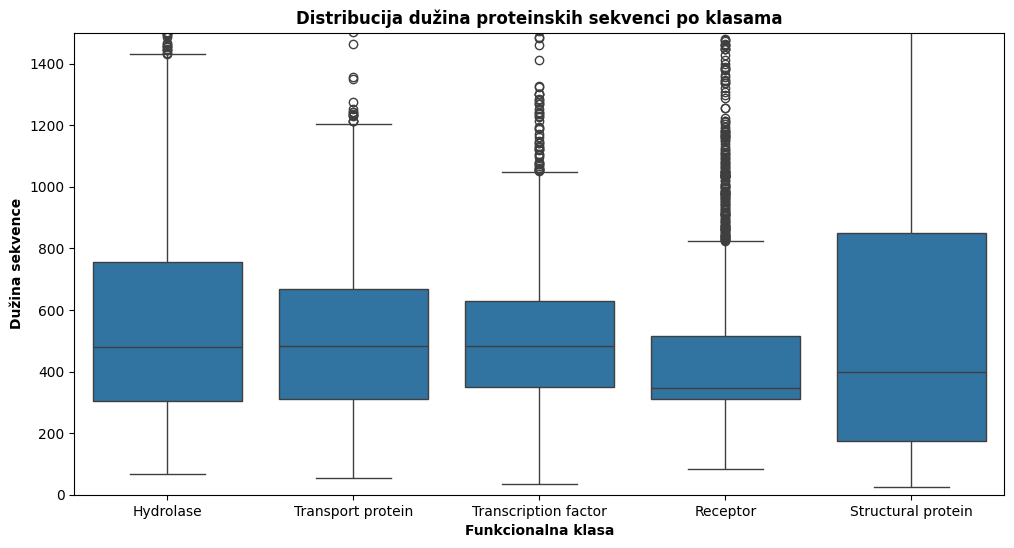

In [16]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="label", y="seq_length", data=dataset)
plt.title("Distribucija dužina proteinskih sekvenci po klasama", fontweight="bold")
plt.xlabel("Funkcionalna klasa", fontweight="bold")
plt.ylabel("Dužina sekvence", fontweight="bold")
plt.ylim(0, 1500)

plt.savefig("results/fig3_length_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

### Analiza sastava aminokiselina po klasi

Cilj ove analize je utvrditi da li određene funckionalne grupe proteina favorizuju specifične aminokiseline. Razlike u frekvenciji aminokiselina direktno utiču na fizičko-hemijska svojstva proteina i njegovu biološku ulogu.

In [17]:
aminoacids = list("ACDEFGHIKLMNPQRSTVWY")

freq_matrix = {}
for label, group in dataset.groupby("label"):
    all = "".join(group['Sequence'].values)
    total = len(all)
    freq_matrix[label] = {aa: round(all.count(aa) / total*100, 2) for aa in aminoacids}

freq_df = pd.DataFrame(freq_matrix).T
print(freq_df)

                         A     C     D     E     F     G     H     I     K  \
Hydrolase             6.80  2.17  5.23  7.02  3.82  6.56  2.66  4.69  5.91   
Receptor              6.88  3.27  3.90  4.67  4.84  6.36  2.51  5.49  3.89   
Structural protein    7.16  2.31  4.89  7.47  2.75  8.44  2.19  4.05  5.94   
Transcription factor  6.97  3.22  3.82  7.29  3.36  7.16  4.21  3.23  6.63   
Transport protein     7.44  2.07  4.04  5.71  5.21  6.99  2.17  5.67  4.51   

                          L     M     N     P     Q     R     S     T     V  \
Hydrolase              9.90  2.18  3.82  5.68  4.62  5.67  7.56  5.18  6.21   
Receptor              11.55  2.41  3.88  5.74  3.62  4.84  8.29  5.96  7.09   
Structural protein     8.36  1.79  3.26  6.98  4.89  5.54  8.31  6.29  6.05   
Transcription factor   7.84  1.81  3.35  7.60  5.27  5.67  9.39  5.38  4.45   
Transport protein     11.63  2.62  3.44  5.18  3.71  4.99  7.65  5.35  6.91   

                         W     Y  
Hydrolase            

#### Heatmapa frekvencije aminokiselina po klasama

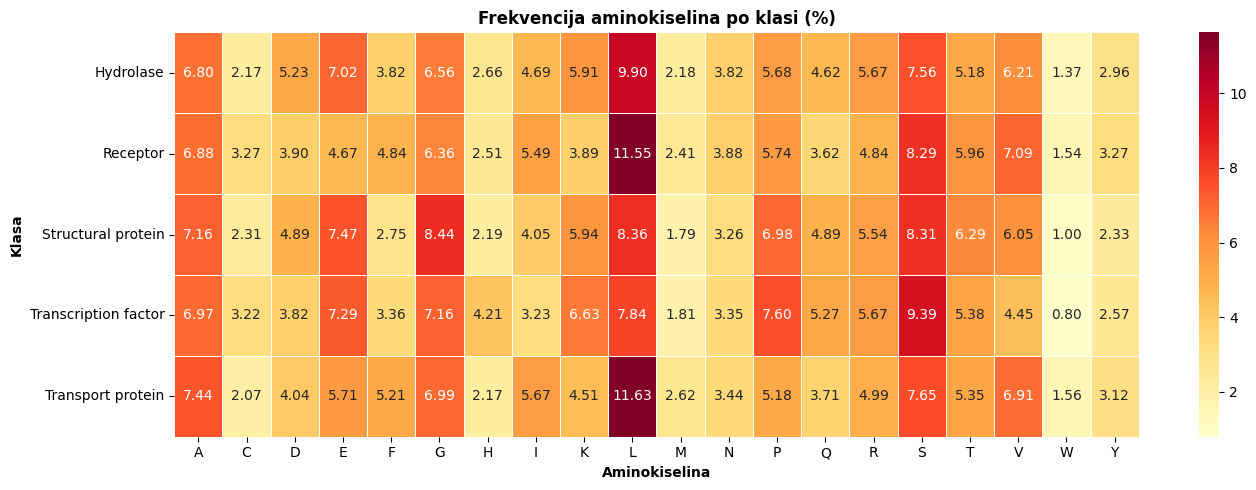

In [18]:
plt.figure(figsize=(14, 5))
sns.heatmap(freq_df, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
plt.title("Frekvencija aminokiselina po klasi (%)", fontweight="bold")
plt.xlabel("Aminokiselina", fontweight="bold")
plt.ylabel("Klasa", fontweight="bold")
plt.tight_layout()

plt.savefig("results/fig4_aac_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### Analiza n-grama po klasi

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [20]:
# Definisanje parametara
ngram_range = (2, 4)
top_n = 20
classes = dataset['label'].unique()

In [21]:
vectorizer = TfidfVectorizer(analyzer='char', ngram_range=ngram_range, max_df=10000, lowercase=False)
vectorizer.fit(dataset['Sequence'])

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",False
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'char'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(

In [22]:
# Izračunavanje prosječnog TF-IDF score-a po klasi
feature_names = vectorizer.get_feature_names_out()
tfidf_per_class = pd.DataFrame(index=classes, columns=feature_names, dtype=float)

for cls in classes:
    class_sequences = dataset[dataset['label'] == cls]['Sequence']
    tfidf_matrix = vectorizer.transform(class_sequences)
    mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
    tfidf_per_class.loc[cls] = mean_tfidf

In [23]:
# Računanje varijanse za svaki n-gram kroz sve klase
ngram_variance = tfidf_per_class.var(axis=0)
# Rangiranje n-grama prema najvećoj varijansi
top_ngrams = ngram_variance.nlargest(top_n).index

heatmap_data = tfidf_per_class[top_ngrams]

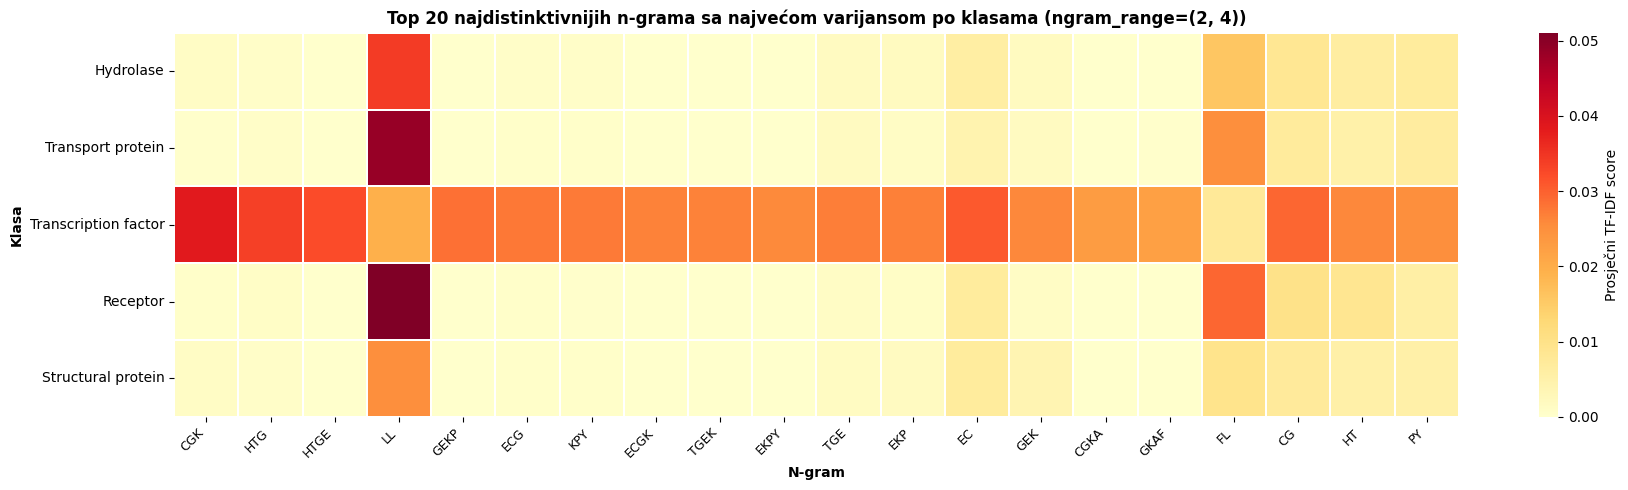

In [24]:
plt.figure(figsize=(18, 5))

sns.heatmap(
    heatmap_data.astype(float),
    cmap='YlOrRd',
    annot=False,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Prosječni TF-IDF score'}
)

plt.title(
    f'Top {top_n} najdistinktivnijih n-grama sa najvećom varijansom po klasama '
    f'(ngram_range={ngram_range})',
    fontweight="bold"
)
plt.xlabel('N-gram', fontweight="bold")
plt.ylabel('Klasa', fontweight="bold")
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('results/fig5_ngram_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Analiza fizičko-hemijskih osobina po klasama

In [44]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from sklearn.preprocessing import StandardScaler

In [45]:
def extract_physicochemical(sequence):
    analysed_seq = ProteinAnalysis(sequence)
    return {
        'MW': analysed_seq.molecular_weight(),
        'pI': analysed_seq.isoelectric_point(),
        'GRAVY': analysed_seq.gravy(), # Hidrofobnost
        'Aromaticity': analysed_seq.aromaticity(),
        'Instability': analysed_seq.instability_index()
    }

In [48]:
ph_features = dataset['Sequence'].apply(lambda x: pd.Series(extract_physicochemical(x)))
ph_features['label'] = dataset['label']

# Srednja vrijednost po klasi
heatmap_data_ph = ph_features.groupby('label').mean()

scaler = StandardScaler()
heatmap_data_scaled = pd.DataFrame(
    scaler.fit_transform(heatmap_data_ph),
    index=heatmap_data_ph.index,
    columns=heatmap_data_ph.columns
)

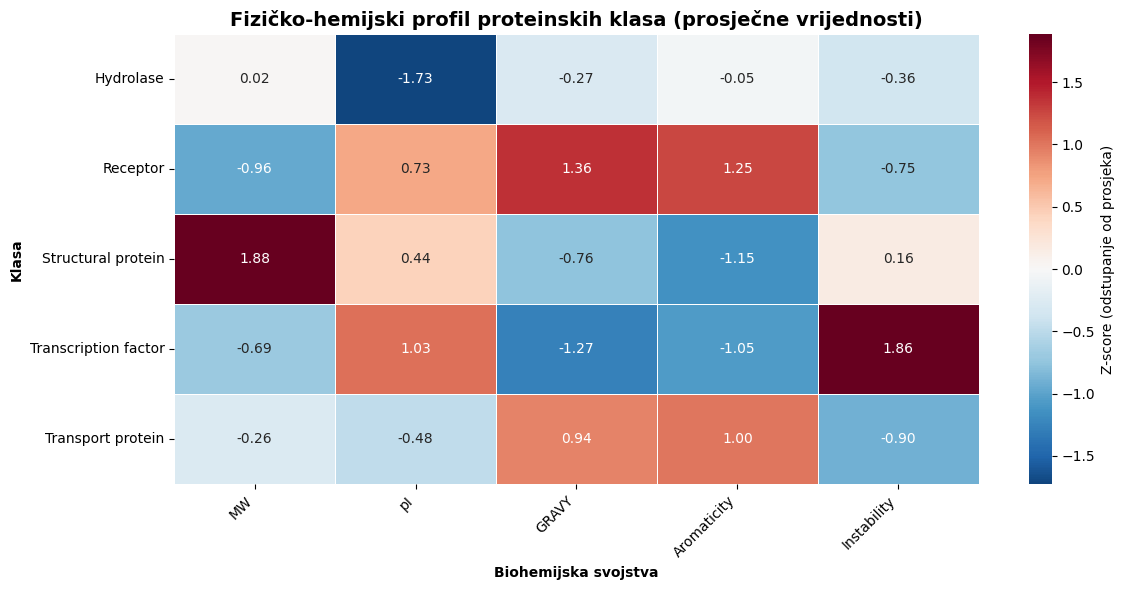

In [50]:

plt.figure(figsize=(12, 6))

# Prikaz divergentne mape 
sns.heatmap(
    heatmap_data_scaled,
    cmap='RdBu_r', 
    annot=True,          
    fmt=".2f",
    linewidths=0.5,
    linecolor='white',
    center=0,            
    cbar_kws={'label': 'Z-score (odstupanje od prosjeka)'}
)

plt.title(
    'Fizičko-hemijski profil proteinskih klasa (prosječne vrijednosti)',
    fontweight="bold", fontsize=14
)
plt.xlabel('Biohemijska svojstva', fontweight="bold")
plt.ylabel('Klasa', fontweight="bold")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig('results/fig6_physicochemical_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Primjena metoda mašinskog učenja

### Podjela skupa na ulazne i ciljne atribute

In [25]:
# Priprema x i y
x = dataset['Sequence'].values
y = dataset['label'].values

### Kodiranje ciljne varijable (Label Encoding)

In [26]:
le = LabelEncoder()
y = le.fit_transform(y)

print("Mapiranje klasa:")
for num, label in enumerate(le.classes_):
    print(f"{num} -> {label}")

Mapiranje klasa:
0 -> Hydrolase
1 -> Receptor
2 -> Structural protein
3 -> Transcription factor
4 -> Transport protein


### Podjela na skup za treniranje i testiranje

In [27]:
# Train/Test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train skup:  {len(x_train)} proteina (80%)")
print(f"Test skup:  {len(x_test)} proteina (20%)")

Train skup:  5330 proteina (80%)
Test skup:  1333 proteina (20%)


### AAC CountVectorizer

In [28]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import Normalizer

In [29]:
amino_acids = ['A','C','D','E','F','G','H','I','K','L',
               'M','N','P','Q','R','S','T','V','W','Y']
cv_acc = CountVectorizer(analyzer='char', vocabulary=amino_acids, lowercase=False)
normalizer = Normalizer(norm='l1')

In [30]:
x_train_aac = normalizer.transform(cv_acc.fit_transform(x_train))
x_test_aac = normalizer.transform(cv_acc.transform(x_test))
print(f"Dimenzije ACC-CV train matrice: {x_train_aac.shape}")
print(f"Dimenzije ACC-CV test matrice: {x_test_aac.shape}")

Dimenzije ACC-CV train matrice: (5330, 20)
Dimenzije ACC-CV test matrice: (1333, 20)


### TF-IDF (Term Frequency-Inverse Document Frequency)

Transformišemo proteinske sekvence u numeričke vektore koristeći **TF-IDF** statistiku. TF-IDF penalizuje n-grame koji se prečesto pojavljuju u svim klasama, a naglašava one koji su jedinstveni za specifične funkcionalne grupe.

In [31]:
tfidf = TfidfVectorizer(
    analyzer='char', 
    ngram_range=(2,4), 
    max_features=5000, 
    lowercase=False)

x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)
print(f"Dimenzije TF-IDF train matrice: {x_train_tfidf.shape}")
print(f"Dimenzije TF-IDF test matrice: {x_test_tfidf.shape}")

Dimenzije TF-IDF train matrice: (5330, 5000)
Dimenzije TF-IDF test matrice: (1333, 5000)


In [32]:
print("Prvih 50 n-grama: ")
print(tfidf.get_feature_names_out()[:50]) 

Prvih 50 n-grama: 
['AA' 'AAA' 'AAAA' 'AAAG' 'AAAL' 'AAC' 'AAD' 'AAE' 'AAF' 'AAG' 'AAH' 'AAI'
 'AAK' 'AAL' 'AAM' 'AAN' 'AAP' 'AAQ' 'AAR' 'AAS' 'AAT' 'AAV' 'AAY' 'AC'
 'ACA' 'ACE' 'ACG' 'ACL' 'ACP' 'ACR' 'ACS' 'ACT' 'ACV' 'AD' 'ADA' 'ADD'
 'ADE' 'ADF' 'ADG' 'ADI' 'ADK' 'ADL' 'ADP' 'ADQ' 'ADR' 'ADS' 'ADT' 'ADV'
 'AE' 'AEA']


### Fizičko-hemijska svojstva

In [51]:
x_train_series = pd.Series(x_train)
x_test_series = pd.Series(x_test)

x_train_ph = x_train_series.apply(lambda x: pd.Series(extract_physicochemical(x)))
x_test_ph = x_test_series.apply(lambda x: pd.Series(extract_physicochemical(x)))

In [52]:
scaler_ph = StandardScaler()
x_train_ph = scaler_ph.fit_transform(x_train_ph)
x_test_ph = scaler_ph.transform(x_test_ph)

### Logistic Regression

In [39]:
from sklearn.linear_model import LogisticRegression

In [40]:
lr_aac = LogisticRegression(
    solver='lbfgs', 
    max_iter=1000,
    class_weight='balanced',
    random_state=42)
lr_aac.fit(x_train_aac, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [41]:
lr_tfidf = LogisticRegression(
    solver='lbfgs', 
    max_iter=1000,
    class_weight='balanced',
    random_state=42)
lr_tfidf.fit(x_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [42]:
lr_ph = LogisticRegression(
    solver='lbfgs', 
    max_iter=1000,
    class_weight='balanced',
    random_state=42)
lr_ph.fit(x_train_ph, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

### Random Forest

In [57]:
from sklearn.ensemble import RandomForestClassifier

In [58]:
rf_aac = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_aac.fit(x_train_aac, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [59]:
rf_tfidf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_tfidf.fit(x_train_tfidf, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [60]:
rf_ph = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_ph.fit(x_train_ph, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### Support Vector Machine (SVM)

In [64]:
from sklearn.svm import SVC

In [65]:
svm_aac = SVC(
    kernel='rbf',
    class_weight='balanced',
    random_state=42
)

svm_aac.fit(x_train_aac, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [66]:
svm_tfidf = SVC(
    kernel='rbf',
    class_weight='balanced',
    random_state=42
)

svm_tfidf.fit(x_train_tfidf, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [67]:
svm_ph = SVC(
    kernel='rbf',
    class_weight='balanced',
    random_state=42
)

svm_ph.fit(x_train_ph, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### Evaluacija modela

In [54]:
from sklearn.metrics import classification_report, accuracy_score

In [53]:
trained_models_lr = {
    'LR | AAC-CV':   (lr_aac,    x_test_aac),
    'LR | TF-IDF':   (lr_tfidf,  x_test_tfidf),
    'LR | PH':       (lr_ph,    x_test_ph),
}

In [55]:
for name, (model, x_te) in trained_models_lr.items():
    y_pred = model.predict(x_te)
    
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{'='*55}")
    print(f"  {name}  |  Accuracy: {acc:.4f}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))


  LR | AAC-CV  |  Accuracy: 0.6189
                      precision    recall  f1-score   support

           Hydrolase       0.66      0.52      0.58       441
            Receptor       0.67      0.67      0.67       276
  Structural protein       0.40      0.49      0.44       142
Transcription factor       0.71      0.91      0.80       269
   Transport protein       0.51      0.48      0.49       205

            accuracy                           0.62      1333
           macro avg       0.59      0.61      0.60      1333
        weighted avg       0.62      0.62      0.61      1333


  LR | TF-IDF  |  Accuracy: 0.7824
                      precision    recall  f1-score   support

           Hydrolase       0.80      0.75      0.78       441
            Receptor       0.89      0.81      0.85       276
  Structural protein       0.56      0.68      0.62       142
Transcription factor       0.90      0.91      0.91       269
   Transport protein       0.65      0.71      0.68     

In [62]:
trained_models_rf = {
    'RF | AAC-CV':   (rf_aac,    x_test_aac),
    'RF | TF-IDF':   (rf_tfidf,  x_test_tfidf),
    'RF | PH':       (rf_ph,   x_test_ph)
}

In [63]:
for name, (model, x_te) in trained_models_rf.items():
    y_pred = model.predict(x_te)
    
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{'='*55}")
    print(f"  {name}  |  Accuracy: {acc:.4f}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))


  RF | AAC-CV  |  Accuracy: 0.7532
                      precision    recall  f1-score   support

           Hydrolase       0.64      0.89      0.75       441
            Receptor       0.87      0.70      0.78       276
  Structural protein       0.87      0.46      0.61       142
Transcription factor       0.86      0.86      0.86       269
   Transport protein       0.76      0.58      0.66       205

            accuracy                           0.75      1333
           macro avg       0.80      0.70      0.73      1333
        weighted avg       0.78      0.75      0.75      1333


  RF | TF-IDF  |  Accuracy: 0.7217
                      precision    recall  f1-score   support

           Hydrolase       0.58      0.95      0.72       441
            Receptor       0.90      0.59      0.72       276
  Structural protein       0.80      0.46      0.59       142
Transcription factor       0.94      0.81      0.87       269
   Transport protein       0.85      0.47      0.60     

In [69]:
trained_models_svm = {
    'SVM | AAC-CV':  (svm_aac,   x_test_aac),
    'SVM | TF-IDF':  (svm_tfidf, x_test_tfidf),
    'SVM | PH':      (svm_ph, x_test_ph)
}

In [70]:
for name, (model, x_te) in trained_models_svm.items():
    y_pred = model.predict(x_te)
    
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{'='*55}")
    print(f"  {name}  |  Accuracy: {acc:.4f}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))


  SVM | AAC-CV  |  Accuracy: 0.7397
                      precision    recall  f1-score   support

           Hydrolase       0.73      0.73      0.73       441
            Receptor       0.81      0.76      0.78       276
  Structural protein       0.56      0.54      0.55       142
Transcription factor       0.85      0.91      0.88       269
   Transport protein       0.64      0.64      0.64       205

            accuracy                           0.74      1333
           macro avg       0.72      0.72      0.72      1333
        weighted avg       0.74      0.74      0.74      1333


  SVM | TF-IDF  |  Accuracy: 0.8215
                      precision    recall  f1-score   support

           Hydrolase       0.75      0.88      0.81       441
            Receptor       0.91      0.84      0.88       276
  Structural protein       0.79      0.62      0.69       142
Transcription factor       0.92      0.92      0.92       269
   Transport protein       0.78      0.68      0.73   

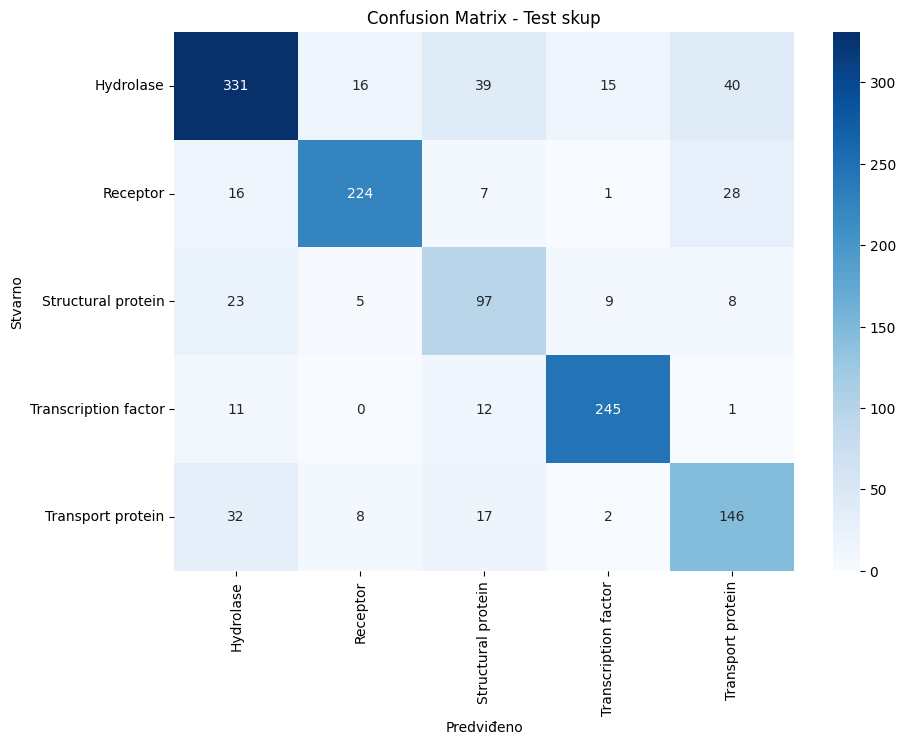

In [172]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predviđeno')
plt.ylabel('Stvarno')
plt.title('Confusion Matrix - Test skup')
plt.show()

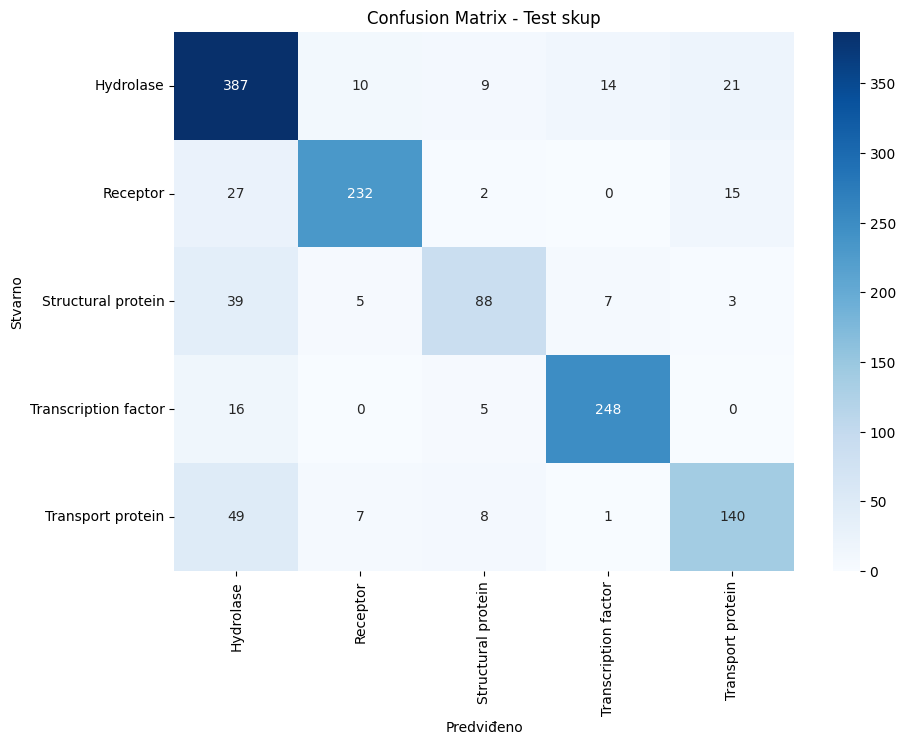

In [ ]:
cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predviđeno')
plt.ylabel('Stvarno')
plt.title('Confusion Matrix SVM - Test skup')
plt.show()

In [186]:
# 1. Pretvaramo sparse matricu u DataFrame radi lakše analize
tfidf_df = pd.DataFrame(x_train_tfidf.toarray(), columns=tfidf.get_feature_names_out())
tfidf_df['label'] = y_train

# 2. Izračunavamo prosječan TF-IDF skor za svaku klasu
# Pretpostavljamo da je 0 = Hydrolase, 4 = Transport protein (provjeri mapiranje iz le.classes_)
mean_tfidf = tfidf_df.groupby('label').mean()

# 3. Tražimo n-grame koji imaju visok skor u OBE klase
# Gledamo proizvod skora - ako je u jednoj klasi 0, proizvod je 0 (nije zajednički)
mean_tfidf.loc['similarity'] = mean_tfidf.loc[0] * mean_tfidf.loc[4]

# 4. Sortiramo i ispisujemo top 10
common_ngrams = mean_tfidf.loc['similarity'].sort_values(ascending=False).head(10)

print("Top 10 n-grama koji su najsličniji/najčešći u obje klase (Hydrolase i Transport):")
print(common_ngrams)

Top 10 n-grama koji su najsličniji/najčešći u obje klase (Hydrolase i Transport):
LL    0.005822
AL    0.002563
LA    0.002527
VL    0.002332
LS    0.002265
LG    0.002264
SL    0.002261
AA    0.002182
GL    0.002142
LV    0.002019
Name: similarity, dtype: float64


### Kombinovani pristup

In [209]:
from scipy.sparse import hstack, csr_matrix

# Spajamo n-grame (TF-IDF) i sastav (AAC)
x_train_combined = hstack([x_train_tfidf, csr_matrix(x_train_aac_scaled)])
x_test_combined = hstack([x_test_tfidf, csr_matrix(x_test_aac_scaled)])

print(f"Novi broj atributa: {x_train_combined.shape[1]}")

Novi broj atributa: 5020


In [210]:
lr_model.fit(x_train_combined, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [211]:
y_pred_lr = lr_model.predict(x_train_combined)

print("KLASIFIKACIONI IZVJEŠTAJ - Trening skup LR:\n")
print(classification_report(y_train, y_pred_lr))

KLASIFIKACIONI IZVJEŠTAJ - Trening skup LR:

              precision    recall  f1-score   support

           0       0.89      0.86      0.87      1763
           1       0.92      0.89      0.90      1102
           2       0.75      0.82      0.78       570
           3       0.91      0.94      0.92      1077
           4       0.84      0.85      0.85       818

    accuracy                           0.87      5330
   macro avg       0.86      0.87      0.87      5330
weighted avg       0.88      0.87      0.88      5330



In [212]:
y_pred_lr = lr_model.predict(x_test_combined)

print("KLASIFIKACIONI IZVJEŠTAJ - Test skup LR:\n")
print(classification_report(y_test, y_pred_lr))

KLASIFIKACIONI IZVJEŠTAJ - Test skup LR:

              precision    recall  f1-score   support

           0       0.79      0.74      0.76       441
           1       0.84      0.80      0.82       276
           2       0.60      0.63      0.61       142
           3       0.88      0.90      0.89       269
           4       0.62      0.70      0.65       205

    accuracy                           0.77      1333
   macro avg       0.74      0.75      0.75      1333
weighted avg       0.77      0.77      0.77      1333



In [213]:
svm_model.fit(x_train_combined, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [216]:
y_pred_svm = svm_model.predict(x_train_combined)

print("KLASIFIKACIONI IZVJEŠTAJ - Trening skup SVM:\n")
print(classification_report(y_train, y_pred_svm))

KLASIFIKACIONI IZVJEŠTAJ - Trening skup SVM:

              precision    recall  f1-score   support

           0       0.83      0.84      0.84      1763
           1       0.87      0.86      0.86      1102
           2       0.86      0.81      0.84       570
           3       0.90      0.95      0.92      1077
           4       0.81      0.79      0.80       818

    accuracy                           0.85      5330
   macro avg       0.85      0.85      0.85      5330
weighted avg       0.85      0.85      0.85      5330



In [217]:
y_pred_svm = svm_model.predict(x_test_combined)

print("KLASIFIKACIONI IZVJEŠTAJ - Trening skup SVM:\n")
print(classification_report(y_test, y_pred_svm))

KLASIFIKACIONI IZVJEŠTAJ - Trening skup SVM:

              precision    recall  f1-score   support

           0       0.75      0.76      0.76       441
           1       0.83      0.79      0.81       276
           2       0.62      0.61      0.62       142
           3       0.87      0.90      0.89       269
           4       0.67      0.69      0.68       205

    accuracy                           0.77      1333
   macro avg       0.75      0.75      0.75      1333
weighted avg       0.77      0.77      0.77      1333

